# Practice Lab B: Linear Maps, Images and PCA

**Area:** linear-algebra · **Related lessons/concepts:** L21–L27; Quizzes 05–06; Homework 05–06

**You will be able to:**


In [1]:
import numpy as np
import sympy as sp
import matplotlib
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

## 1. A shape and some transformations

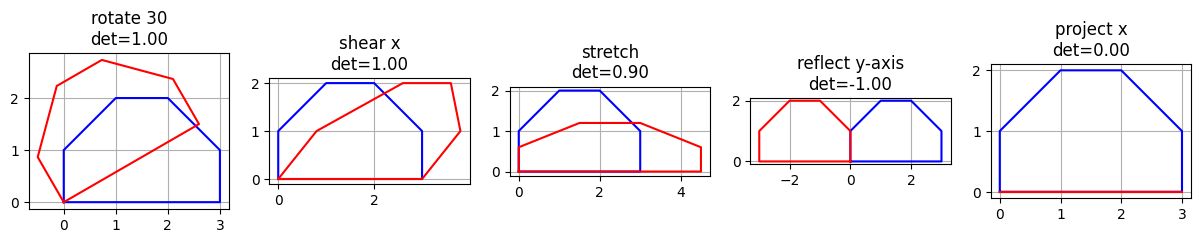

In [2]:
shape=np.array([[0,3,3,2,1,0,0],[0,0,1,2,2,1,0]],float)   # a little house outline
def R(a): a=np.radians(a); return np.array([[np.cos(a),-np.sin(a)],[np.sin(a),np.cos(a)]])
T={"rotate 30":R(30),"shear x":np.array([[1,.8],[0,1]]),"stretch":np.diag([1.5,.6]),"reflect y-axis":np.diag([-1,1]),"project x":np.diag([1,0])}
fig,axs=plt.subplots(1,5,figsize=(15,3))
for ax,(k,Mx) in zip(axs,T.items()):
    ax.plot(*shape,'b-'); ax.plot(*(Mx@shape),'r-'); ax.set_title(f"{k}\ndet={np.linalg.det(Mx):.2f}"); ax.set_aspect('equal'); ax.grid(True)
plt.show()

## 2. Composition and inverse

In [3]:
A=T["rotate 30"]@T["shear x"]       # shear first, then rotate
back=np.linalg.inv(A)@(A@shape); print(np.allclose(back,shape), np.linalg.det(A))

True 1.0


## 3. Low-rank image compression (synthetic picture)

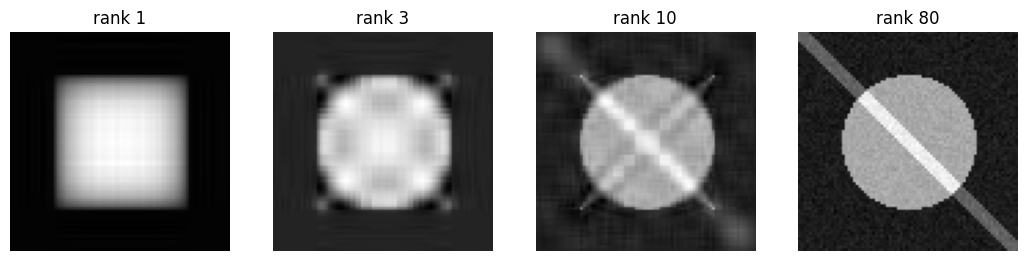

1 kept energy: 0.8723
3 kept energy: 0.9244
10 kept energy: 0.963
40 kept energy: 0.9969


In [4]:
yy,xx=np.mgrid[0:80,0:80]; img=((xx-40)**2+(yy-40)**2<600).astype(float)+0.5*(np.abs(xx-yy)<4)+0.05*np.random.default_rng(0).normal(size=(80,80))
U,s,Vt=np.linalg.svd(img,full_matrices=False)
fig,axs=plt.subplots(1,4,figsize=(13,3.4))
for ax,k in zip(axs,(1,3,10,80)):
    ax.imshow((U[:,:k]*s[:k])@Vt[:k],cmap='gray'); ax.set_title(f"rank {k}"); ax.axis('off')
plt.show()
for k in (1,3,10,40): print(k, "kept energy:", round((s[:k]**2).sum()/(s**2).sum(),4))

## 4. PCA on 2-D data via eigenvectors

eigenvalues [10.6185  0.5055] first PC [-0.8876 -0.4605]


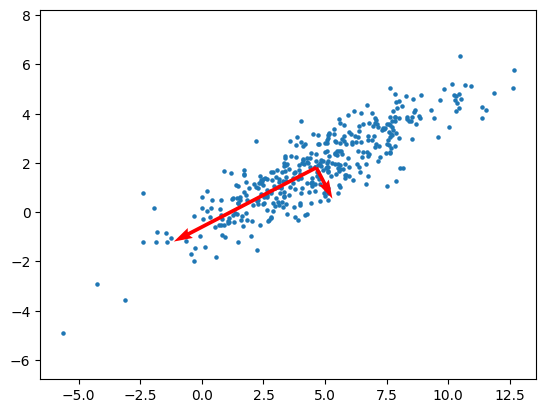

1-D representation keeps 0.955 of the variance


In [5]:
rng=np.random.default_rng(1); X=rng.normal(size=(400,2))@np.array([[3,1.5],[0,0.8]])+[5,2]
Xc=X-X.mean(0); w,V=np.linalg.eigh(np.cov(Xc.T)); print("eigenvalues",w[::-1],"first PC",V[:,-1])
plt.scatter(*X.T,s=5); 
for i in (0,1): plt.quiver(*X.mean(0),*(2*np.sqrt(w[i])*V[:,i]),angles='xy',scale_units='xy',scale=1,color='r')
plt.axis('equal'); plt.show()
Z=Xc@V[:,-1:]; print("1-D representation keeps",round(w[-1]/w.sum(),3),"of the variance")

## Exercises

**Exercise 1.** Show that applying R(30) twelve times returns every point to its start.

In [6]:
# your code here

**Exercise 2.** How many singular values are needed to keep 99% of the image energy?

In [7]:
# your code here

## Solutions
*(Try the exercises first!)*

In [8]:
# Solution 1
P=np.linalg.matrix_power(R(30),12)@shape; assert np.allclose(P,shape)

In [9]:
# Solution 2
k=int(np.searchsorted(np.cumsum(s**2)/(s**2).sum(),0.99)+1); print(k); assert k<40

23
